# House Price Prediction System

Dataset: House Prices - Advanced Regression Techniques (Kaggle/OpenML)

This notebook implements an end-to-end ML workflow in 11 phases.

## Imports and Setup

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

## PHASE 1: Problem Understanding

- **Business problem:** Predict residential house selling price from property attributes to support pricing, valuation, and negotiation decisions.
- **Target variable:** `SalePrice`
- **Feature types:** Numerical (e.g., area, year built, quality scores) and categorical (e.g., zoning, neighborhood, roof style).
- **Why regression:** `SalePrice` is a continuous numeric variable, so we estimate a real-valued output.
- **Success criteria:** Optimize **RMSE** (on test and CV), while also reporting MAE and R2. RMSE penalizes large pricing errors more strongly.

## PHASE 2: Data Understanding

In [4]:
def load_house_data():
    local_candidates = [
        Path('train.csv'),
        Path('data/train.csv'),
        Path('../train.csv'),
        Path('../data/train.csv')
    ]

    for p in local_candidates:
        if p.exists():
            return pd.read_csv(p), f'Local file: {p.resolve()}'

    try:
        openml = fetch_openml(name='house_prices', version=1, as_frame=True)
        df_openml = openml.frame.copy()
        if 'SalePrice' not in df_openml.columns and openml.target is not None:
            df_openml['SalePrice'] = pd.to_numeric(openml.target, errors='coerce')
        return df_openml, 'OpenML: house_prices (version=1)'
    except Exception as ex:
        raise FileNotFoundError(
            'Dataset not found locally and OpenML download failed. '
            'Place Kaggle train.csv in the notebook folder (or data/train.csv). '
            f'Original error: {ex}'
        )

df_raw, data_source = load_house_data()
print('Data source:', data_source)
display(df_raw.head())
print('Shape:', df_raw.shape)

print('\nData types:')
display(df_raw.dtypes.value_counts())

print('\nStatistical summary (numerical):')
display(df_raw.describe().T)

print('\nStatistical summary (categorical):')
display(df_raw.describe(include='object').T)

Data source: Local file: D:\Users\Admin\Desktop\AI&Data\Day28\House_Price_Preduction\train.csv


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Shape: (1460, 81)

Data types:


str        43
int64      35
float64     3
Name: count, dtype: int64


Statistical summary (numerical):


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Statistical summary (categorical):


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## PHASE 3: Data Cleaning

In [5]:
df = df_raw.copy()

missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).sort_values(ascending=False)
missing_report = pd.DataFrame({'MissingCount': missing_counts, 'MissingPercent': missing_pct}).sort_values('MissingPercent', ascending=False)

print('Top missing columns:')
display(missing_report.head(20))

drop_cols = missing_report[missing_report['MissingPercent'] > 40].index.tolist()
print(f'Columns to drop (>40% missing): {len(drop_cols)}')
print(drop_cols)
df = df.drop(columns=drop_cols)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in numeric_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

for c in categorical_cols:
    if df[c].isnull().any():
        mode_val = df[c].mode(dropna=True)
        fill_val = mode_val.iloc[0] if not mode_val.empty else 'Missing'
        df[c] = df[c].fillna(fill_val)

before_dups = len(df)
df = df.drop_duplicates().copy()
after_dups = len(df)
print(f'Duplicates removed: {before_dups - after_dups}')

num_cols_for_outlier = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_rows = []
for c in num_cols_for_outlier:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    cnt = ((df[c] < lower) | (df[c] > upper)).sum()
    outlier_rows.append((c, cnt))

outlier_df = pd.DataFrame(outlier_rows, columns=['Feature', 'OutlierCount']).sort_values('OutlierCount', ascending=False)
print('Outlier counts by feature (IQR method):')
display(outlier_df.head(15))

extreme_cols = [c for c in ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF'] if c in df.columns]
extreme_mask = pd.Series(False, index=df.index)
for c in extreme_cols:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    extreme_mask = extreme_mask | (df[c] < lower) | (df[c] > upper)

df = df.loc[~extreme_mask].copy()
print(f'Extreme outlier rows removed: {extreme_mask.sum()}')
print('Cleaned shape:', df.shape)

Top missing columns:


,MissingCount,MissingPercent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945
GarageQual,81,5.547945


Columns to drop (>40% missing): 6
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
Duplicates removed: 0
Outlier counts by feature (IQR method):


,Feature,OutlierCount
5,OverallCond,125
2,LotFrontage,106
1,MSSubClass,103
8,MasVnrArea,98
25,OpenPorchSF,77
3,LotArea,69
11,TotalBsmtSF,61
28,SalePrice,61
18,BedroomAbvGr,35
24,WoodDeckSF,32


Extreme outlier rows removed: 46
Cleaned shape: (1414, 75)


## PHASE 4: Exploratory Data Analysis

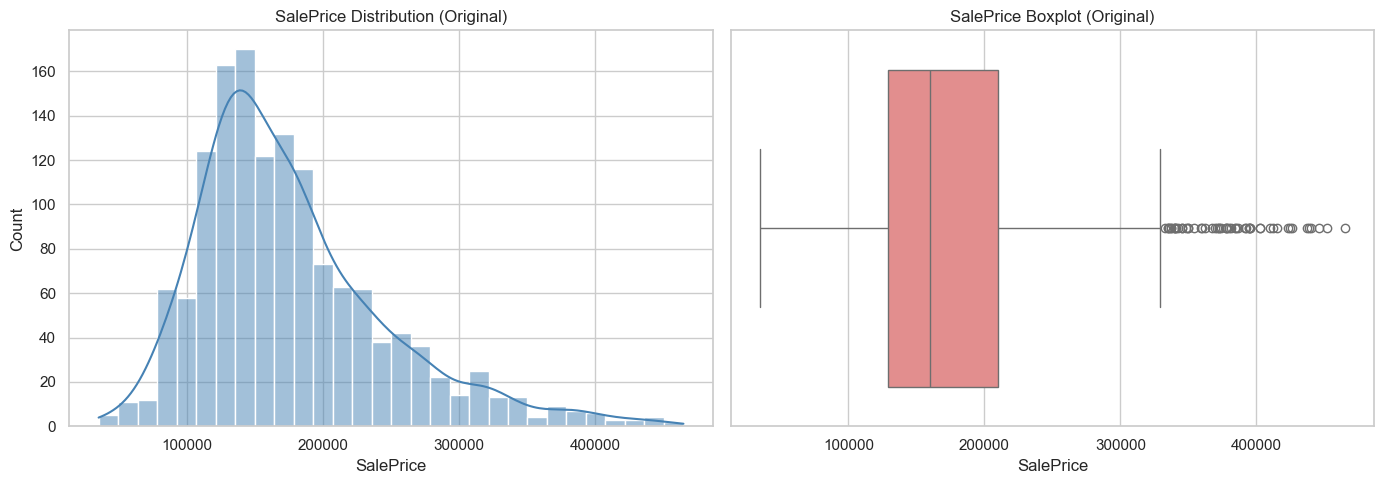

Skewness of SalePrice: 1.1544
Applied log1p transformation to SalePrice -> using SalePrice_Log as model target.


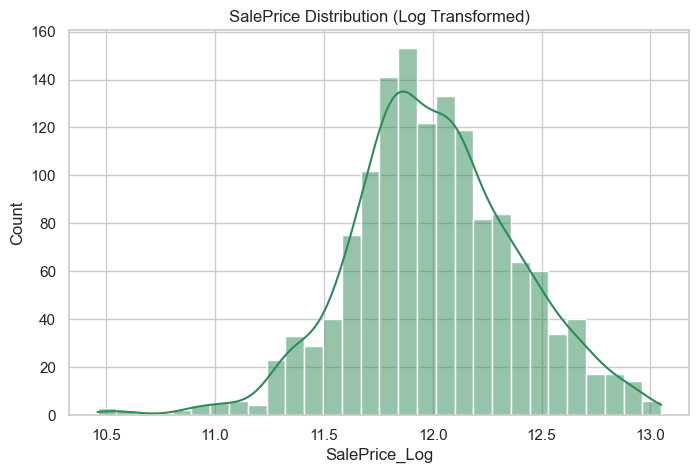

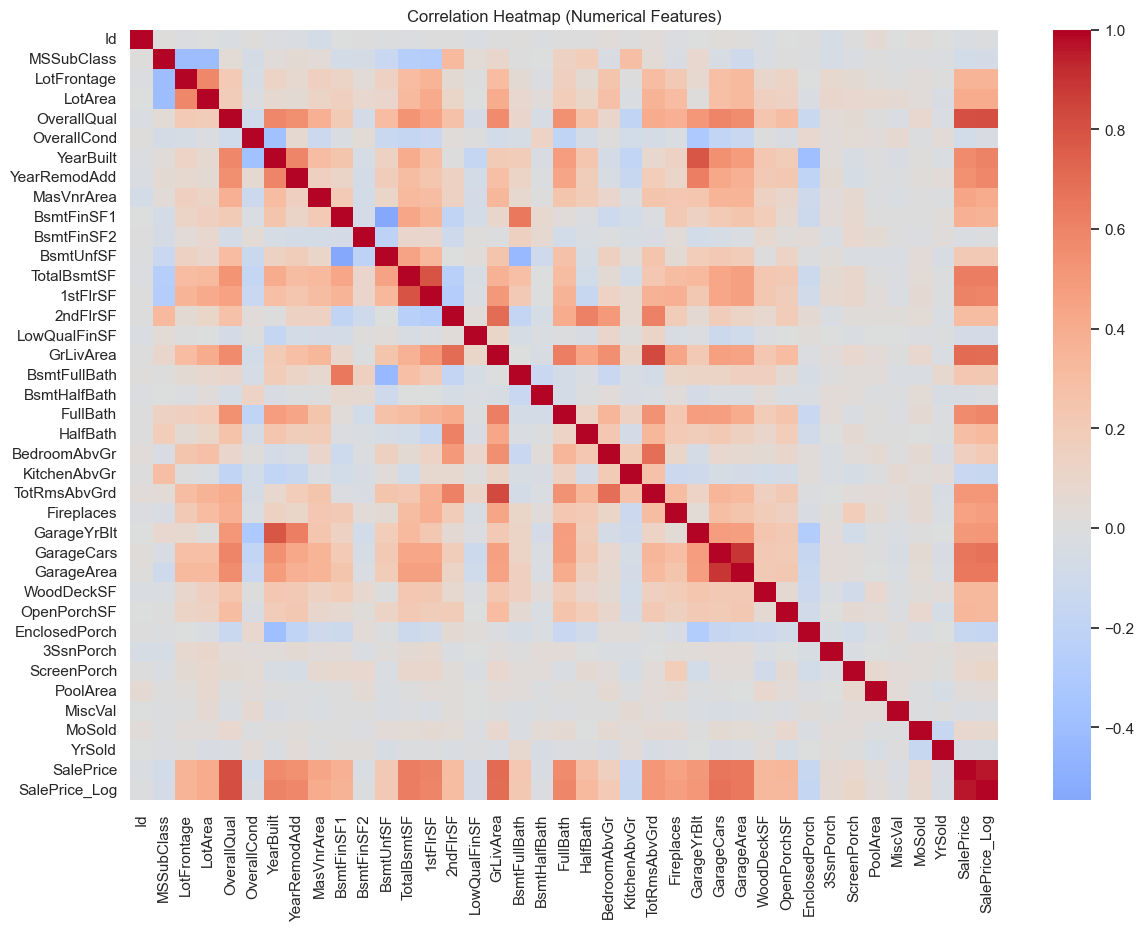

Top 10 features correlated with SalePrice:


,AbsCorrelationWithSalePrice
SalePrice_Log,0.962667
OverallQual,0.811920
GrLivArea,0.705548
GarageCars,0.661994
GarageArea,0.649680
TotalBsmtSF,0.629856
1stFlrSF,0.606680
YearBuilt,0.570243
FullBath,0.562879
YearRemodAdd,0.547146


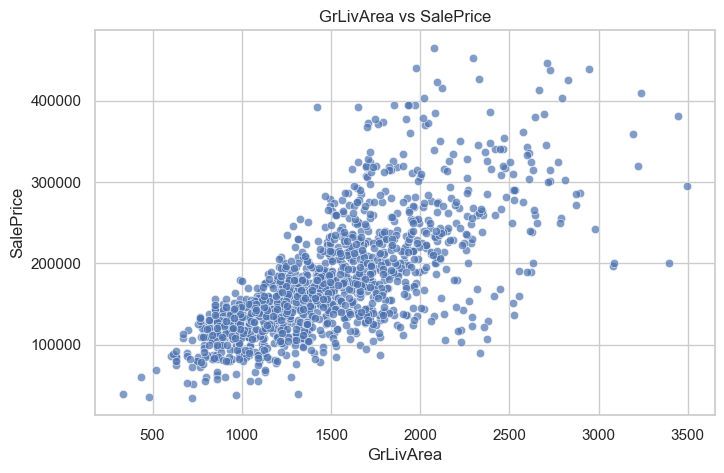

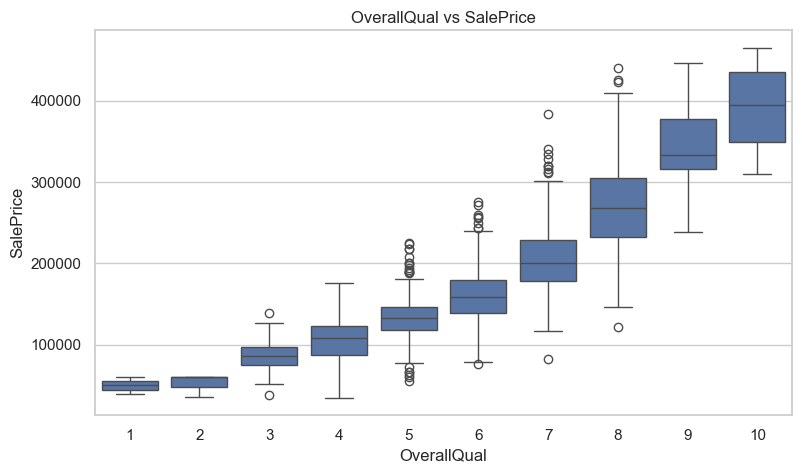

In [6]:
if 'SalePrice' not in df.columns:
    raise ValueError('SalePrice column is required but was not found.')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0], color='steelblue')
ax[0].set_title('SalePrice Distribution (Original)')

sns.boxplot(x=df['SalePrice'], ax=ax[1], color='lightcoral')
ax[1].set_title('SalePrice Boxplot (Original)')
plt.tight_layout()
plt.show()

saleprice_skew = df['SalePrice'].skew()
print(f'Skewness of SalePrice: {saleprice_skew:.4f}')

TARGET_COL = 'SalePrice'
if saleprice_skew > 0.75:
    df['SalePrice_Log'] = np.log1p(df['SalePrice'])
    TARGET_COL = 'SalePrice_Log'
    print('Applied log1p transformation to SalePrice -> using SalePrice_Log as model target.')

    plt.figure(figsize=(8, 5))
    sns.histplot(df['SalePrice_Log'], kde=True, color='seagreen')
    plt.title('SalePrice Distribution (Log Transformed)')
    plt.show()
else:
    print('Log transform not needed based on skewness threshold.')

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, cbar=True)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

top_corr = corr_matrix['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(10)
print('Top 10 features correlated with SalePrice:')
display(top_corr.to_frame('AbsCorrelationWithSalePrice'))

if 'GrLivArea' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.7)
    plt.title('GrLivArea vs SalePrice')
    plt.show()

if 'OverallQual' in df.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x='OverallQual', y='SalePrice')
    plt.title('OverallQual vs SalePrice')
    plt.show()

## PHASE 5: Feature Engineering

In [7]:
df_model = df.copy()

bath_components = {
    'FullBath': 1.0,
    'HalfBath': 0.5,
    'BsmtFullBath': 1.0,
    'BsmtHalfBath': 0.5
}

df_model['TotalBathrooms'] = 0.0
for c, w in bath_components.items():
    if c in df_model.columns:
        df_model['TotalBathrooms'] += df_model[c] * w

if 'YrSold' in df_model.columns and 'YearBuilt' in df_model.columns:
    df_model['HouseAge'] = df_model['YrSold'] - df_model['YearBuilt']
else:
    df_model['HouseAge'] = np.nan

if df_model['HouseAge'].isna().any():
    df_model['HouseAge'] = df_model['HouseAge'].fillna(df_model['HouseAge'].median())

if 'Id' in df_model.columns:
    df_model = df_model.drop(columns=['Id'])

target_cols_to_drop = ['SalePrice']
if TARGET_COL == 'SalePrice_Log':
    target_cols_to_drop.append('SalePrice_Log')

y = df_model[TARGET_COL]
X = df_model.drop(columns=target_cols_to_drop)

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
)

print('Feature engineering complete.')
print('X shape:', X.shape)
print('Numerical features:', len(num_features))
print('Categorical features:', len(cat_features))
print('Model target:', TARGET_COL)

Feature engineering complete.
X shape: (1414, 75)
Numerical features: 38
Categorical features: 37
Model target: SalePrice_Log


## PHASE 6: Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Why split? To evaluate generalization on unseen data and detect overfitting.')
print('Training set size:', X_train.shape, y_train.shape)
print('Testing set size:', X_test.shape, y_test.shape)

Why split? To evaluate generalization on unseen data and detect overfitting.
Training set size: (1131, 75) (1131,)
Testing set size: (283, 75) (283,)


## PHASE 7: Model Building

In [9]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=300, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

trained_pipelines = {}
train_perf = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred_train = pipe.predict(X_train)
    r2_train = r2_score(y_train, pred_train)

    trained_pipelines[name] = pipe
    train_perf.append({'Model': name, 'Train_R2': r2_train})

train_perf_df = pd.DataFrame(train_perf).sort_values('Train_R2', ascending=False)
print('Training performance comparison:')
display(train_perf_df)

Training performance comparison:


,Model,Train_R2
1,DecisionTree,1.000000
2,RandomForest,0.983561
3,GradientBoosting,0.966096
0,LinearRegression,0.953221


## PHASE 8: Cross Validation (5-Fold)

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=None)
    cv_results.append({
        'Model': name,
        'CV_R2_Mean': scores.mean(),
        'CV_R2_Std': scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV_R2_Mean', ascending=False)
display(cv_df)
best_model_name = cv_df.iloc[0]['Model']
print('Best model based on 5-fold CV R2:', best_model_name)

,Model,CV_R2_Mean,CV_R2_Std
3,GradientBoosting,0.904330,0.016172
0,LinearRegression,0.900028,0.013169
2,RandomForest,0.872462,0.019573
1,DecisionTree,0.717987,0.047549


Best model based on 5-fold CV R2: GradientBoosting


## PHASE 9: Model Evaluation

In [11]:
eval_rows = []

for name, pipe in trained_pipelines.items():
    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    eval_rows.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'Overfit_Gap': r2_train - r2_test
    })

eval_df = pd.DataFrame(eval_rows).sort_values('RMSE')
display(eval_df)

best_test_model_name = eval_df.iloc[0]['Model']
print('Best model on test RMSE:', best_test_model_name)

,Model,MAE,RMSE,R2_Train,R2_Test,Overfit_Gap
3,GradientBoosting,0.086059,0.128422,0.966096,0.882485,0.083611
0,LinearRegression,0.091044,0.135957,0.953221,0.868290,0.084931
2,RandomForest,0.091966,0.139248,0.983561,0.861836,0.121724
1,DecisionTree,0.150697,0.209123,1.000000,0.688385,0.311615


Best model on test RMSE: GradientBoosting


## PHASE 10: Model Improvement (Hyperparameter Tuning)

In [12]:
base_best_name = best_model_name
base_best_model = models[base_best_name]

if base_best_name == 'RandomForest':
    param_grid = {
        'model__n_estimators': [300, 500],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    }
elif base_best_name == 'GradientBoosting':
    param_grid = {
        'model__n_estimators': [200, 400],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.8, 1.0]
    }
elif base_best_name == 'DecisionTree':
    param_grid = {
        'model__max_depth': [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
else:
    param_grid = {
        'model__fit_intercept': [True, False],
        'model__positive': [False]
    }

tune_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', base_best_model)
])

grid = GridSearchCV(
    estimator=tune_pipe,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=None,
    verbose=0
)

grid.fit(X_train, y_train)
best_tuned_model = grid.best_estimator_

print('Best tuning params:')
print(grid.best_params_)
print('Best CV R2 after tuning:', grid.best_score_)

y_pred_train_tuned = best_tuned_model.predict(X_train)
y_pred_test_tuned = best_tuned_model.predict(X_test)

tuned_metrics = {
    'Model': f'{base_best_name} (Tuned)',
    'MAE': mean_absolute_error(y_test, y_pred_test_tuned),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test_tuned)),
    'R2_Train': r2_score(y_train, y_pred_train_tuned),
    'R2_Test': r2_score(y_test, y_pred_test_tuned)
}
tuned_metrics['Overfit_Gap'] = tuned_metrics['R2_Train'] - tuned_metrics['R2_Test']

tuned_df = pd.DataFrame([tuned_metrics])
print('Tuned model performance:')
display(tuned_df)

Best tuning params:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best CV R2 after tuning: 0.918886005925032
Tuned model performance:


,Model,MAE,RMSE,R2_Train,R2_Test,Overfit_Gap
0,GradientBoosting (Tuned),0.08218,0.122621,0.976385,0.892861,0.083524


## PHASE 11: Final Analysis

In [13]:
final_r2_train = tuned_metrics['R2_Train']
final_r2_test = tuned_metrics['R2_Test']
gap = tuned_metrics['Overfit_Gap']

if gap > 0.10:
    bv_note = 'Variance is relatively high (overfitting risk): training performance is much better than testing.'
elif gap < 0.02:
    bv_note = 'Bias may be relatively higher (possible underfitting): train and test scores are very close.'
else:
    bv_note = 'Bias-variance tradeoff appears reasonably balanced for this dataset and feature set.'

print('Bias-Variance Interpretation:')
print(bv_note)

if TARGET_COL == 'SalePrice_Log':
    unit_note = 'Metrics are computed on log-transformed SalePrice. Interpret differences in relative/percentage-like terms.'
else:
    unit_note = 'Metrics are computed in original currency units of SalePrice.'

print('\nBusiness interpretation:')
print(
    f"The tuned {base_best_name} model provides a test R2 of {final_r2_test:.4f} and RMSE of {tuned_metrics['RMSE']:.4f}. "
    'This means the model captures a substantial share of price variation and can support pricing decisions, '
    'property valuation screening, and negotiation guidance. For production use, periodic retraining and drift checks are recommended.'
)
print(unit_note)

Bias-Variance Interpretation:
Bias-variance tradeoff appears reasonably balanced for this dataset and feature set.

Business interpretation:
The tuned GradientBoosting model provides a test R2 of 0.8929 and RMSE of 0.1226. This means the model captures a substantial share of price variation and can support pricing decisions, property valuation screening, and negotiation guidance. For production use, periodic retraining and drift checks are recommended.
Metrics are computed on log-transformed SalePrice. Interpret differences in relative/percentage-like terms.
